In [ ]:
import pandas as pd
import re
import unicodedata

In [ ]:
!unzip -q "/content/drive/MyDrive/data.zip" -d /content/marathi_csv_data

replace /content/marathi_csv_data/data/marathi_test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
y
y
replace /content/marathi_csv_data/data/marathi_train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: replace /content/marathi_csv_data/data/marathi_val.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y


In [12]:
df_train = pd.read_csv('./drive/MyDrive/stage_2_dataset_2_csv/indic_marathi/train.csv')
df_train.head()

,id,input,target,url
0,1,उपमुख्यमंत्री अजित पवार ः आम्ही सर्वजण उद्धव ठ...,मतभिन्नता असली तरी महाविकास आघाडी मजबूतच - अजि...,https://www.dainikprabhat.com/despite-differen...
1,2,टीम महाराष्ट्र देशा : भारतीय हवाई दलाने नियंत्...,"मुख्यमंत्री आणि पोलीस यांच्यातील बैठक संपली , ...",https://maharashtradesha.com/indian-air-strike...
2,3,सांगली - सांगली शहरातील 100 फुटी रोड परिसरात न...,सांगलीत अज्ञातांकडून वाहनांची जाळपोळ,https://www.dainikprabhat.com/vehicles-burnt-b...
3,4,ऱ्या पावसामुळे महाराष्ट्रावर भीषण दुष्काळाचे ...,जालन्यात पाणी टंचाईने घेतला महिलेचा जीव,https://amnews.live/news/maharashtra/womans-bo...
4,5,मुंबईत मुख्यमंत्री देवेंद्र फडणवीस यांच्या हस्...,लोकशाहीर अण्णाभाऊ साठे यांच्या टपाल तिकिटाचे ग...,https://www.dainikprabhat.com/publication-of-p...


In [86]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
df_test = pd.read_csv('./drive/MyDrive/stage_2_dataset_2_csv/indic_marathi/test.csv')
df_test.head()

,id,input,target,url
0,1,नगर : प्रतिनिधी राज्यातील जलयुक्त शिवार अभियान...,भूजल पुनरुज्जीवन'मध्ये नगर जिल्हा सर्वोत्कृष्ट,https://www.pudhari.news/news/Ahamadnagar/aham...
1,2,पणजी : प्रतिनिधी बाबूश मोन्सेरात बलात्कार प्रक...,पीडित युवती बेपत्ता प्रकरणी चौकशीचे आदेश : मुख...,https://www.pudhari.news/news/Goa/goa-chief-mi...
2,3,टीम महाराष्ट्र देशा - उस्मानाबाद जिल्हा खरीप प...,उस्मानाबाद जिल्हा खरीप पीक-विम्यातून वगळल्याच्...,https://maharashtradesha.com/swamimani-protest...
3,4,व्हॅलेंटाईन डे'निमित्त गुलाबाची आवक वाढली मागण...,पुणे - बाजारात 'गुलाबी' हवा,https://www.dainikprabhat.com/pink-air-in-the-...
4,5,ठाणे : पुढारी ऑनलाईन राम मंदिरासाठी शिवसेनेने ...,शिवसेनेच्या राम मंदिर आंदोलनाचे आम्ही स्वागत क...,https://www.pudhari.news/news/Mumbai-Thane-Rai...


In [15]:
df_val = pd.read_csv("./drive/MyDrive/stage_2_dataset_2_csv/indic_marathi/validation.csv")
df_val.head()

,id,input,target,url
0,1,औरंगाबाद : प्रतिनिधी 'त्यांनी मला खूप छळलंय.,"मला खूप छळलंय, त्यांनाही छळा",https://www.pudhari.news/news/Aurangabad/Polic...
1,2,विहिरीमध्ये अज्ञात इसमाचा मृतदेह आढळल्याने खळब...,मोदींची मुख्यमंत्रीपदाची कारकिर्द देशावरचा डाग...,https://www.dainikprabhat.com/modis-chief-mini...
2,3,मुंबईः काल रात्रीपासून मुंबईत सुरु असलेल्या जो...,महापौर विश्वनाथ महाडेश्वरांंनंतर उद्धव ठाकरेंच...,https://maharashtradesha.com/uddhav-thackerays...
3,4,टीम महाराष्ट्र देशा : राज्यात विधानसभा निवडणुक...,शरद पवारांच्या 'या' भूमिकेचा शिवसेनेला बसला दणका,https://maharashtradesha.com/sharad-pawar-said...
4,5,पुणे : प्रतिनिधी शालेय विद्यार्थ्यांची सुरक्षि...,"शाळा, पालकांमुळे खासगी वाहतूक फोफावणार",https://www.pudhari.news/news/Pune/Private-tra...


In [17]:
df_train = df_train[['input', 'target']]
df_train.head()

,input,target
0,उपमुख्यमंत्री अजित पवार ः आम्ही सर्वजण उद्धव ठ...,मतभिन्नता असली तरी महाविकास आघाडी मजबूतच - अजि...
1,टीम महाराष्ट्र देशा : भारतीय हवाई दलाने नियंत्...,"मुख्यमंत्री आणि पोलीस यांच्यातील बैठक संपली , ..."
2,सांगली - सांगली शहरातील 100 फुटी रोड परिसरात न...,सांगलीत अज्ञातांकडून वाहनांची जाळपोळ
3,ऱ्या पावसामुळे महाराष्ट्रावर भीषण दुष्काळाचे ...,जालन्यात पाणी टंचाईने घेतला महिलेचा जीव
4,मुंबईत मुख्यमंत्री देवेंद्र फडणवीस यांच्या हस्...,लोकशाहीर अण्णाभाऊ साठे यांच्या टपाल तिकिटाचे ग...


In [19]:
df_test = df_test[['input', 'target']]
df_test.head()

,input,target
0,नगर : प्रतिनिधी राज्यातील जलयुक्त शिवार अभियान...,भूजल पुनरुज्जीवन'मध्ये नगर जिल्हा सर्वोत्कृष्ट
1,पणजी : प्रतिनिधी बाबूश मोन्सेरात बलात्कार प्रक...,पीडित युवती बेपत्ता प्रकरणी चौकशीचे आदेश : मुख...
2,टीम महाराष्ट्र देशा - उस्मानाबाद जिल्हा खरीप प...,उस्मानाबाद जिल्हा खरीप पीक-विम्यातून वगळल्याच्...
3,व्हॅलेंटाईन डे'निमित्त गुलाबाची आवक वाढली मागण...,पुणे - बाजारात 'गुलाबी' हवा
4,ठाणे : पुढारी ऑनलाईन राम मंदिरासाठी शिवसेनेने ...,शिवसेनेच्या राम मंदिर आंदोलनाचे आम्ही स्वागत क...


In [20]:
df_val = df_val[['input', 'target']]
df_val.head()

,input,target
0,औरंगाबाद : प्रतिनिधी 'त्यांनी मला खूप छळलंय.,"मला खूप छळलंय, त्यांनाही छळा"
1,विहिरीमध्ये अज्ञात इसमाचा मृतदेह आढळल्याने खळब...,मोदींची मुख्यमंत्रीपदाची कारकिर्द देशावरचा डाग...
2,मुंबईः काल रात्रीपासून मुंबईत सुरु असलेल्या जो...,महापौर विश्वनाथ महाडेश्वरांंनंतर उद्धव ठाकरेंच...
3,टीम महाराष्ट्र देशा : राज्यात विधानसभा निवडणुक...,शरद पवारांच्या 'या' भूमिकेचा शिवसेनेला बसला दणका
4,पुणे : प्रतिनिधी शालेय विद्यार्थ्यांची सुरक्षि...,"शाळा, पालकांमुळे खासगी वाहतूक फोफावणार"


In [21]:
len(df_train), len(df_test), len(df_val)

(86574, 10857, 10827)

In [22]:
df_train = df_train[df_train["input"].str.strip() != ""]
df_train = df_train[df_train["target"].str.strip() != ""]
df_train = df_train[df_train["input"] != df_train["target"]]

In [23]:
df_test = df_test[df_test["input"].str.strip() != ""]
df_test = df_test[df_test["target"].str.strip() != ""]
df_test = df_test[df_test["input"] != df_test["target"]]

In [24]:
df_val = df_val[df_val['input'].str.strip() != ""]
df_val = df_val[df_val["target"].str.strip() != ""]
df_val = df_val[df_val['input'] != df_val['target']]

In [26]:
df_train = df_train.dropna()
df_test = df_test.dropna()
df_val = df_val.dropna()

In [27]:
len(df_train), len(df_test), len(df_val)

(86574, 10857, 10827)

In [28]:
def normalize_text(text):
    text = unicodedata.normalize("NFC", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [32]:
df_train["input"] = df_train['input'].apply(normalize_text)
df_train['target'] = df_train["target"].apply(normalize_text)

In [33]:
df_test["input"] = df_test["input"].apply(normalize_text)
df_test["target"] = df_test["target"].apply(normalize_text)

In [34]:
df_val["input"] = df_val["input"].apply(normalize_text)
df_val["target"] = df_val["target"].apply(normalize_text)

In [35]:
import matplotlib.pyplot as plt

In [36]:
def character_len_dist(df: pd.DataFrame):
  input_len = df["input"].str.len()
  target_len = df["target"].str.len()

  len_df = pd.DataFrame({"input_len": input_len, "target_len": target_len})

  print(len_df.describe(percentiles=[0.01,0.05,0.1,0.25,0.5,0.75,0.9,0.95,0.99]))

  plt.figure(figsize=(20,10))

  len_df.hist(bins=100, figsize=(20,10))
  plt.tight_layout()
  plt.show()

          input_len    target_len
count  62793.000000  62793.000000
mean     135.615642     53.471597
std       43.908185     14.046837
min       51.000000     31.000000
1%        61.000000     31.000000
5%        75.000000     34.000000
10%       85.000000     36.000000
25%      104.000000     42.000000
50%      129.000000     52.000000
75%      161.000000     63.000000
90%      195.000000     74.000000
95%      218.000000     79.000000
99%      265.000000     88.000000
max      319.000000     94.000000


<Figure size 2000x1000 with 0 Axes>

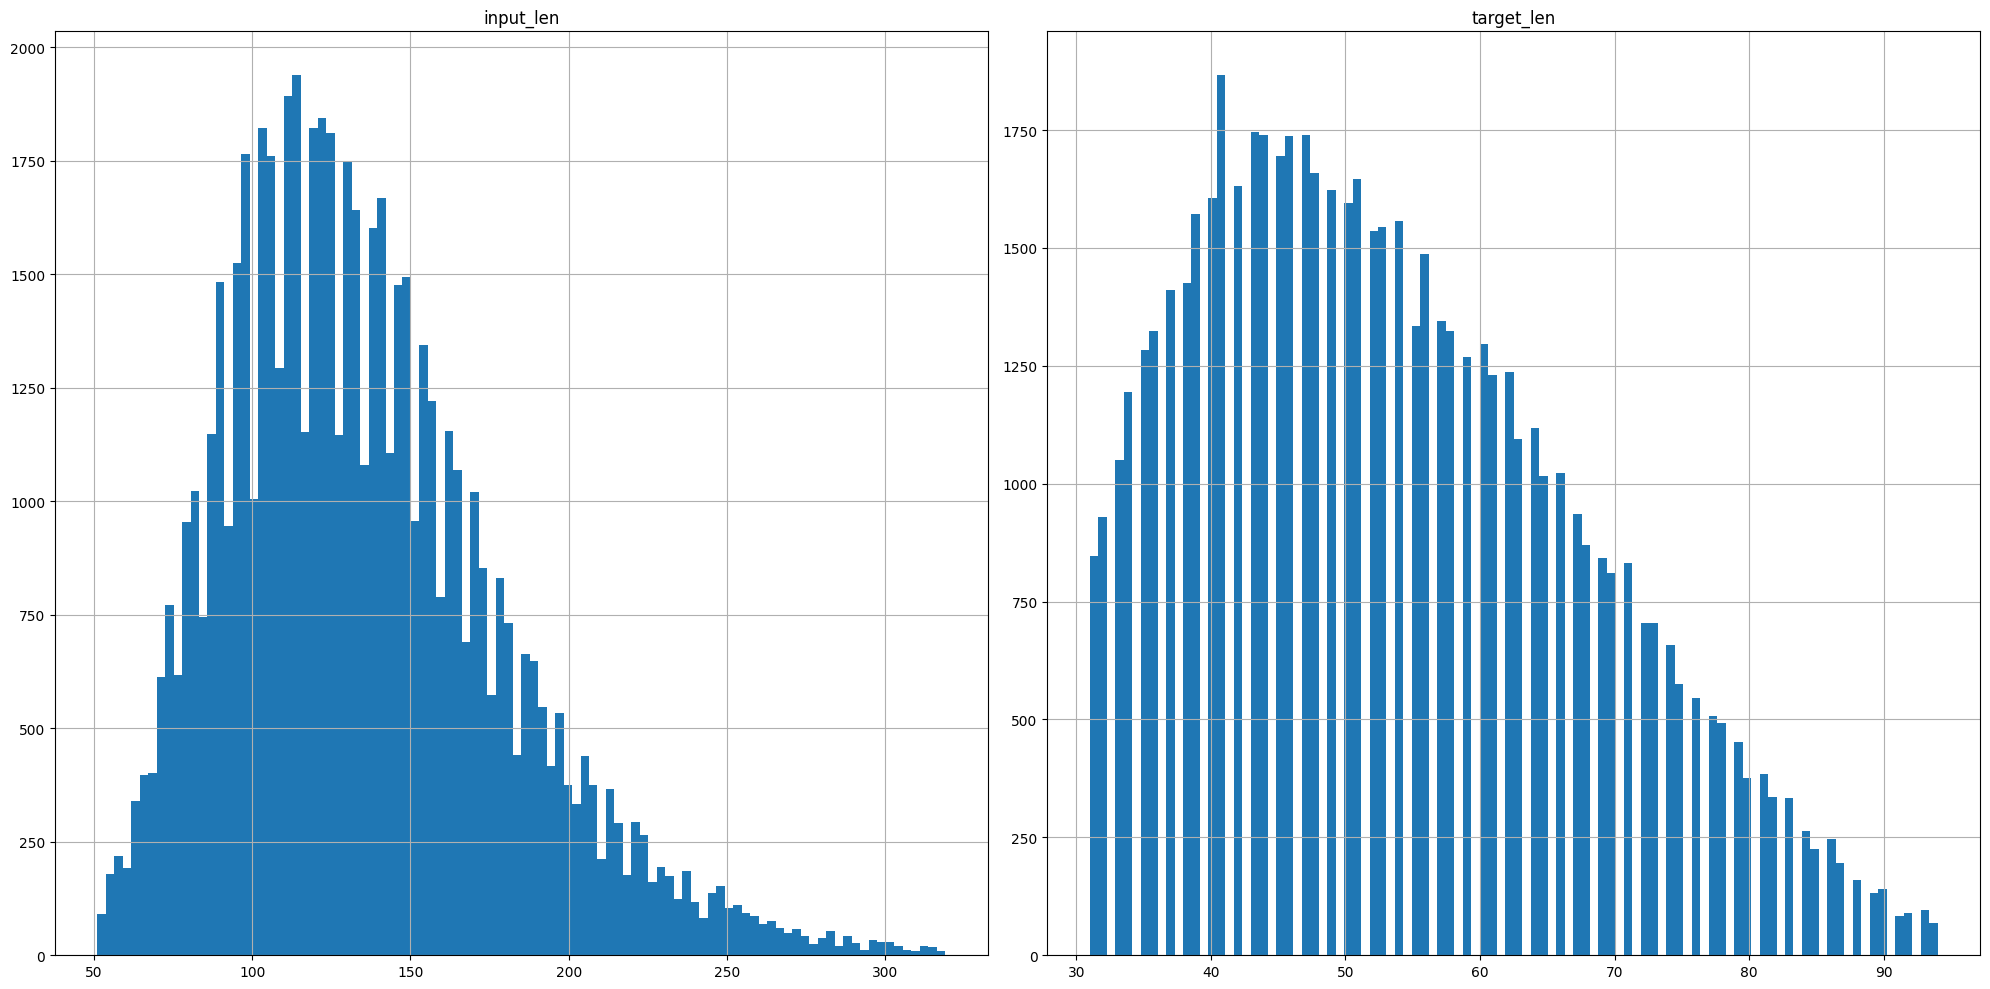

In [103]:
character_len_dist(df_train)

         input_len   target_len
count  7902.000000  7902.000000
mean    135.623386    53.436598
std      43.434785    14.187445
min      51.000000    31.000000
1%       65.000000    31.000000
5%       77.000000    34.000000
10%      86.000000    36.000000
25%     103.000000    42.000000
50%     130.000000    51.000000
75%     160.000000    63.000000
90%     193.000000    74.000000
95%     216.000000    80.000000
99%     270.000000    89.000000
max     318.000000    94.000000


<Figure size 2000x1000 with 0 Axes>

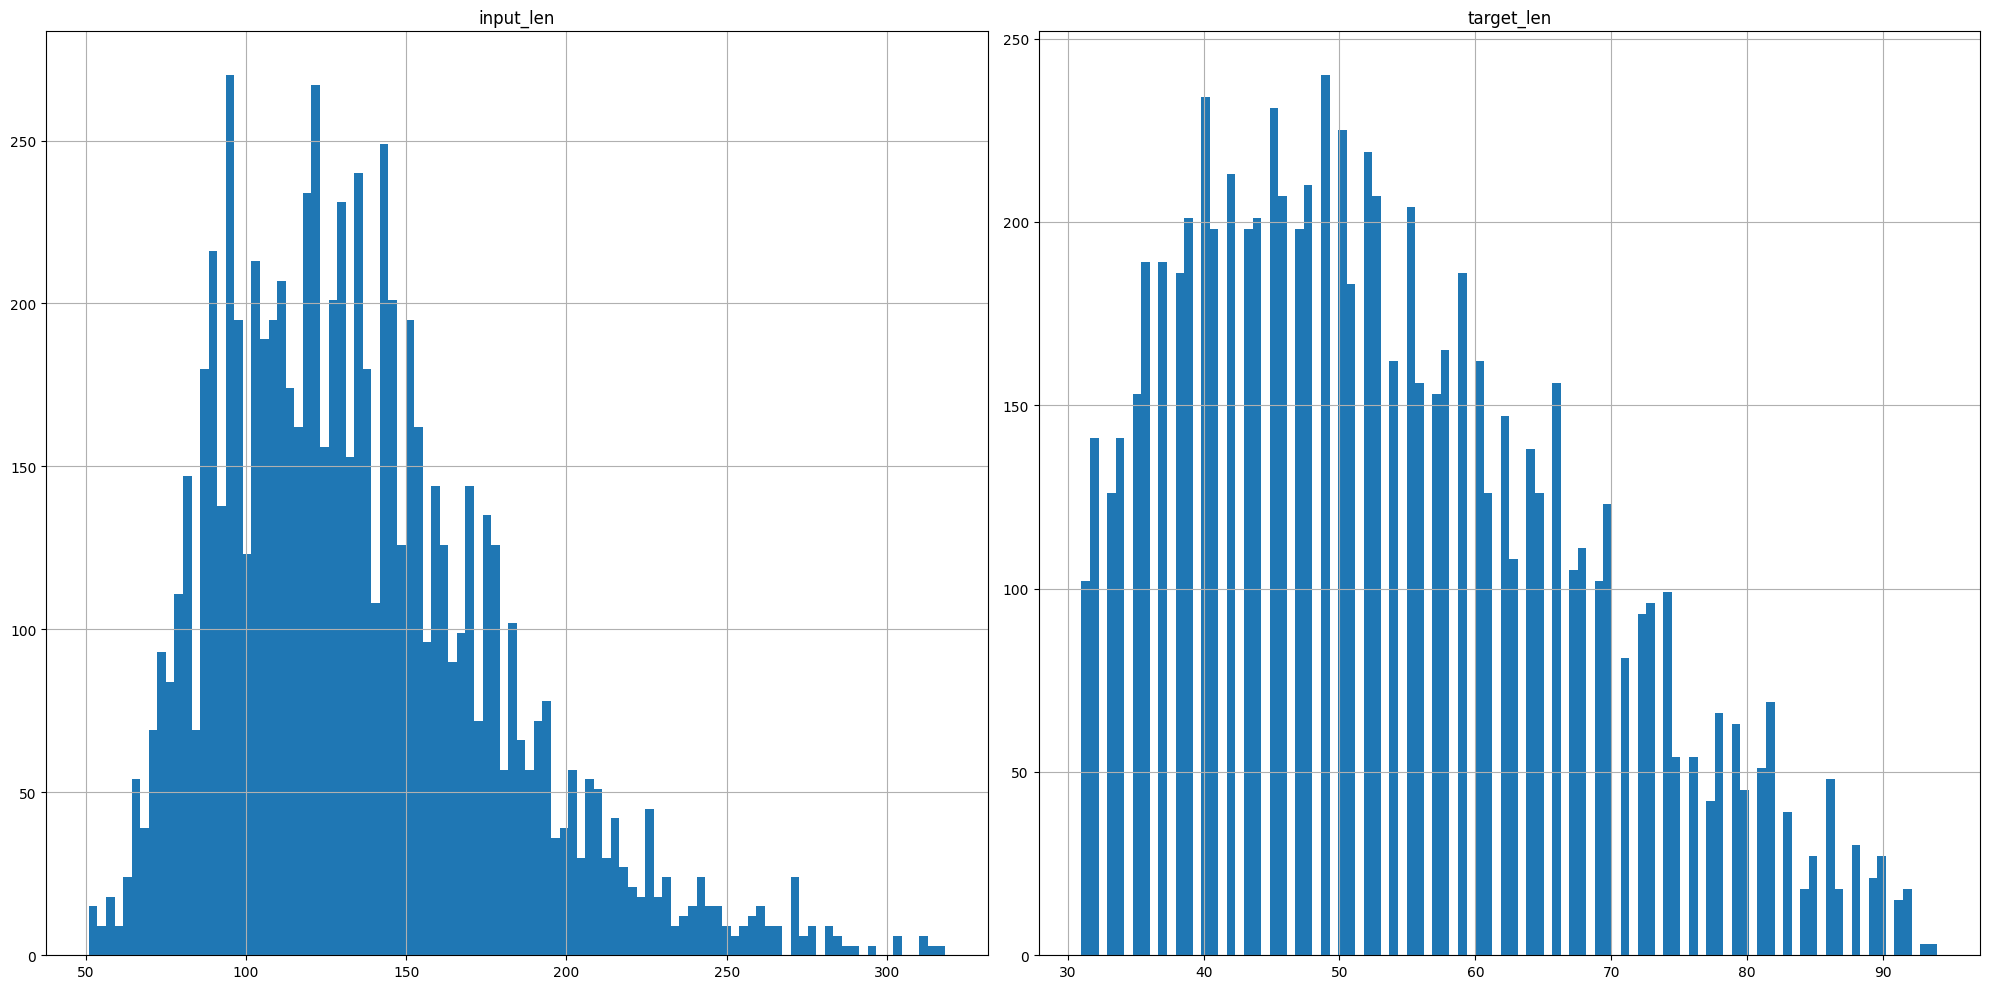

In [104]:
character_len_dist(df_test)

         input_len   target_len
count  8010.000000  8010.000000
mean    135.143071    53.573783
std      44.833180    14.123207
min      52.000000    31.000000
1%       62.000000    31.000000
5%       76.000000    34.000000
10%      85.000000    36.000000
25%     102.000000    42.000000
50%     128.000000    52.000000
75%     161.000000    63.000000
90%     197.000000    74.000000
95%     220.000000    79.000000
99%     266.910000    89.000000
max     319.000000    94.000000


<Figure size 2000x1000 with 0 Axes>

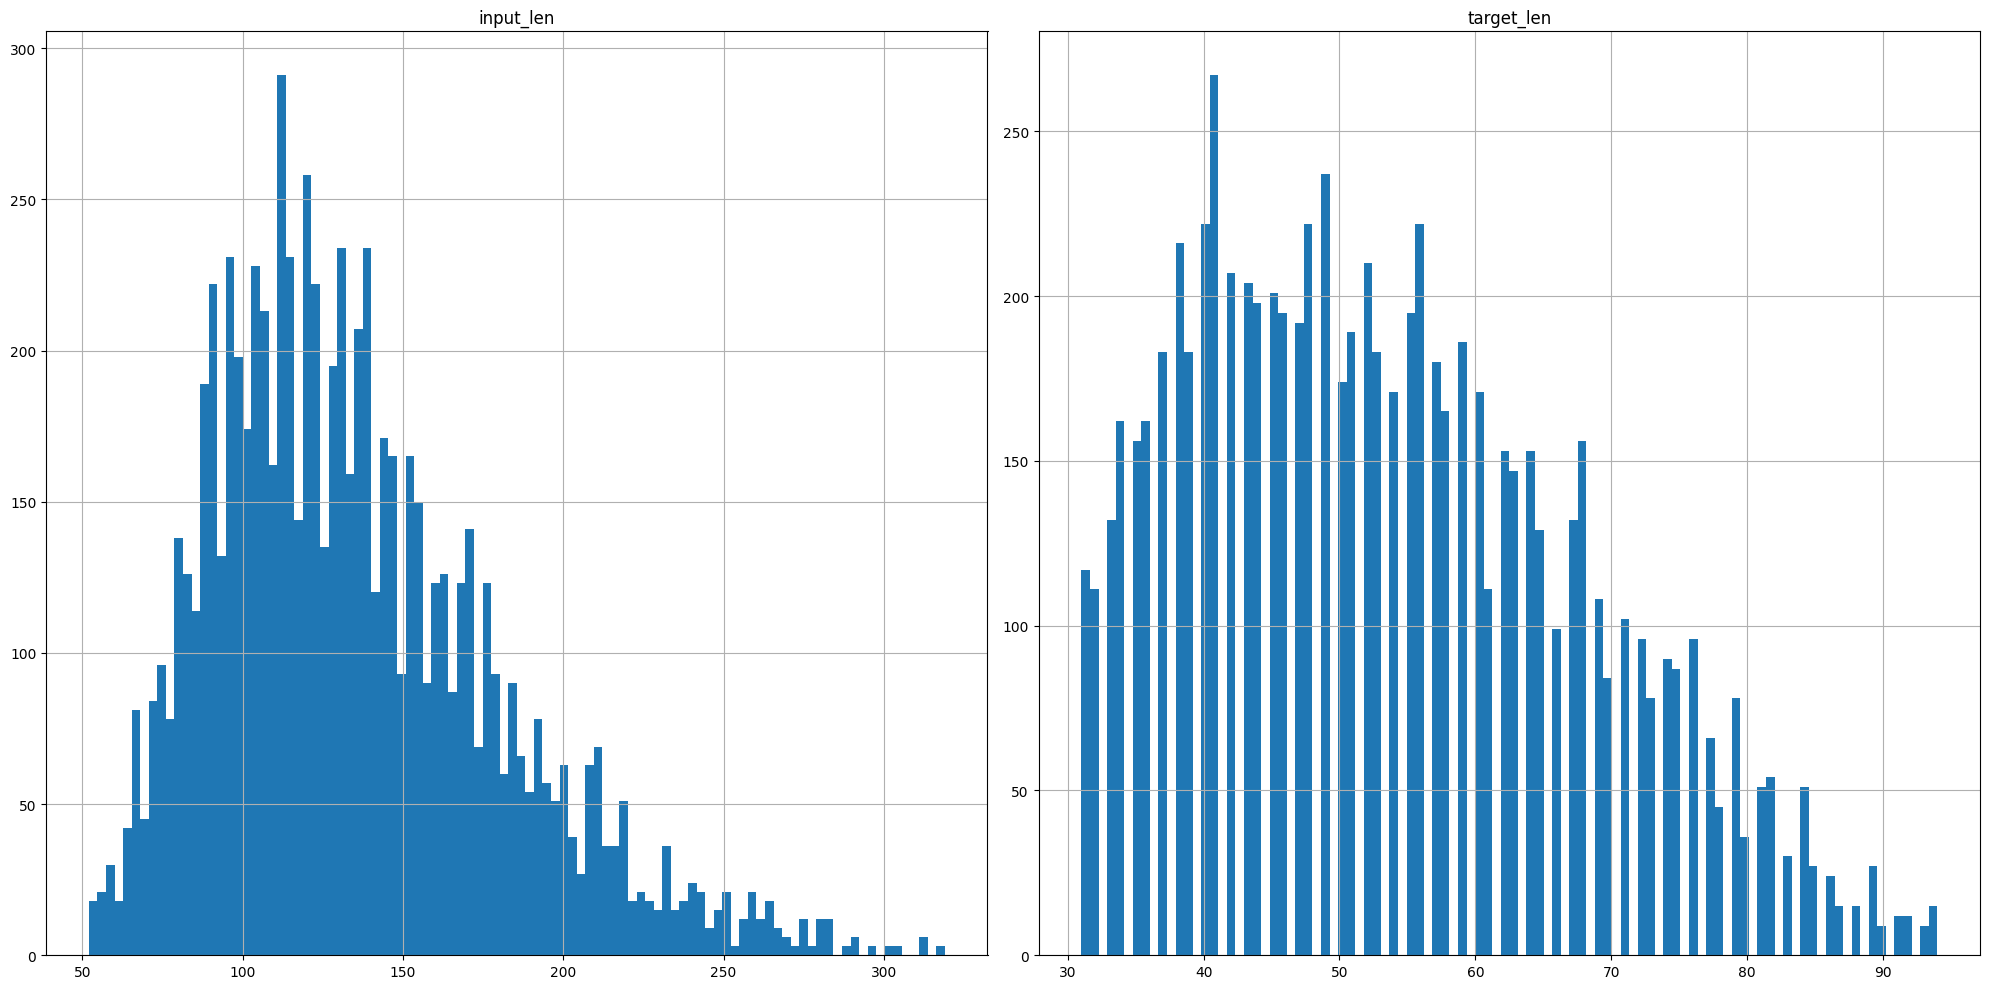

In [105]:
character_len_dist(df_val)

In [44]:
len(df_train), len(df_test), len(df_val)

(77436, 9795, 9786)

In [42]:
def clean_by_len(df: pd.DataFrame):
  input_len = df["input"].str.len()
  target_len = df['target'].str.len()

  return df[
    (input_len > 50) &
    (input_len < 320) &
    (target_len > 30) &
    (target_len < 95)
 ]

In [43]:
df_train = clean_by_len(df_train)

df_test = clean_by_len(df_test)

df_val = clean_by_len(df_val)

In [45]:
def character_ratio_dist(df: pd.DataFrame):
  # Compute lengths
  input_len = df["input"].str.len()
  target_len = df["target"].str.len()

  # Compute ratio
  len_ratio = target_len / input_len

  # Basic statistics
  print("Character Ratio Statistics:")
  print(len_ratio.describe(percentiles=[0.01,0.05,0.1,0.25,0.5,0.75,0.9,0.95,0.99]))

  plt.figure()
  plt.hist(len_ratio, bins=100)
  plt.xlabel("Summary / Article (Character Ratio)")
  plt.ylabel("Frequency")
  plt.title("Character Ratio Distribution")
  plt.show()

Character Ratio Statistics:
count    62793.000000
mean         0.426339
std          0.147418
min          0.200000
1%           0.204878
5%           0.222973
10%          0.243781
25%          0.301887
50%          0.405172
75%          0.537500
90%          0.648148
95%          0.696078
99%          0.739130
max          0.750000
dtype: float64


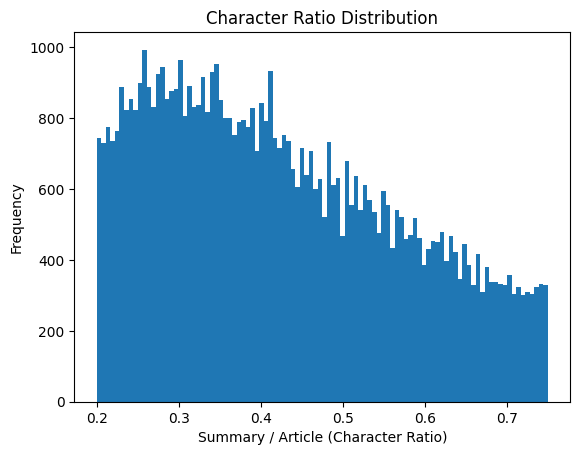

Character Ratio Statistics:
count    7902.000000
mean        0.425244
std         0.147546
min         0.200000
1%          0.203822
5%          0.222222
10%         0.241611
25%         0.300000
50%         0.403846
75%         0.536364
90%         0.646018
95%         0.694428
99%         0.739130
max         0.750000
dtype: float64


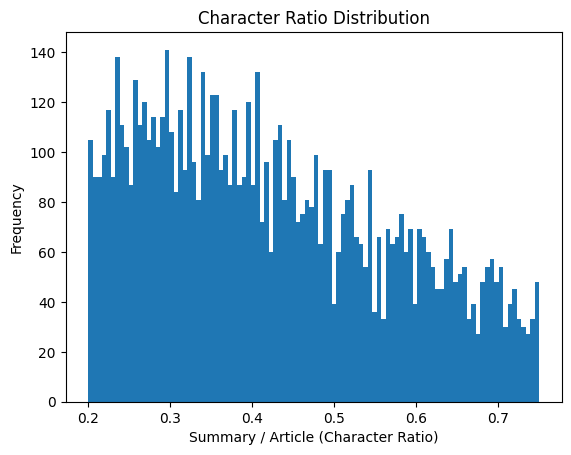

Character Ratio Statistics:
count    8010.000000
mean        0.429660
std         0.149452
min         0.200000
1%          0.203140
5%          0.226316
10%         0.245455
25%         0.302857
50%         0.406171
75%         0.544776
90%         0.653916
95%         0.700000
99%         0.738984
max         0.750000
dtype: float64


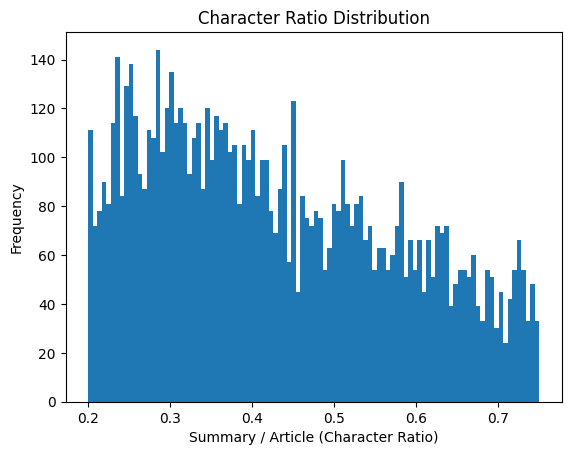

In [102]:
character_ratio_dist(df_train)
character_ratio_dist(df_test)
character_ratio_dist(df_val)

In [ ]:
len(df_train), len(df_test), len(df_val)

(9226, 1159, 1149)

In [50]:
def clean_by_ratio(df: pd.DataFrame):
  # Compute lengths
  input_len = df['input'].str.len()
  target_len = df['target'].str.len()

  # Compute ratio
  len_ratio = target_len / input_len

  return df[(len_ratio >= 0.20) & (len_ratio <= 0.75)]

In [51]:
df_train = clean_by_ratio(df_train)

In [52]:
df_test = clean_by_ratio(df_test)

In [53]:
df_val = clean_by_ratio(df_val)

In [54]:
len(df_train), len(df_test), len(df_val)

(62793, 7902, 8010)

In [55]:
def too_similar(article, summary):
    return summary in article

In [56]:
df_train = df_train[~df_train.apply(lambda x: too_similar(x["input"], x["target"]), axis=1)]

In [57]:
df_test = df_test[~df_test.apply(lambda x: too_similar(x["input"], x["target"]), axis=1)]

In [58]:
df_val = df_val[~df_val.apply(lambda x: too_similar(x['input'], x["target"]), axis=1)]

In [65]:
len(df_train), len(df_test), len(df_val)

(62793, 7902, 8010)

In [60]:
def clean_format(text):
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text

In [61]:
df_train["input"] = df_train["input"].apply(clean_format)
df_train["target"] = df_train["target"].apply(clean_format)

In [62]:
df_test["input"] = df_test['input'].apply(clean_format)
df_test["target"] = df_test["target"].apply(clean_format)

In [63]:
df_val['input'] = df_val["input"].apply(clean_format)
df_val['target'] = df_val["target"].apply(clean_format)

In [64]:
df_train.isna().sum()

,0
input,0
target,0


In [66]:
def calc_marathi_ratio(text):
  allowed = re.findall(r'[\u0900-\u097F0-9\s.,!?;:%()\-"]', text)
  return len(allowed)/len(text)

In [69]:
import re

def marathi_ratio_dist(df: pd.DataFrame):

  marathi_ratio = df['input'].apply(calc_marathi_ratio)

  print(marathi_ratio.describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99]))

  plt.figure()
  plt.hist(marathi_ratio, bins=50)
  plt.xlabel("Marathi Ratio")
  plt.ylabel("Frequency")
  plt.title("Marathi Ratio Distribution")
  plt.show()

count    62793.000000
mean         0.999237
std          0.003437
min          0.949367
1%           0.981818
5%           0.993289
10%          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
90%          1.000000
95%          1.000000
99%          1.000000
max          1.000000
Name: input, dtype: float64


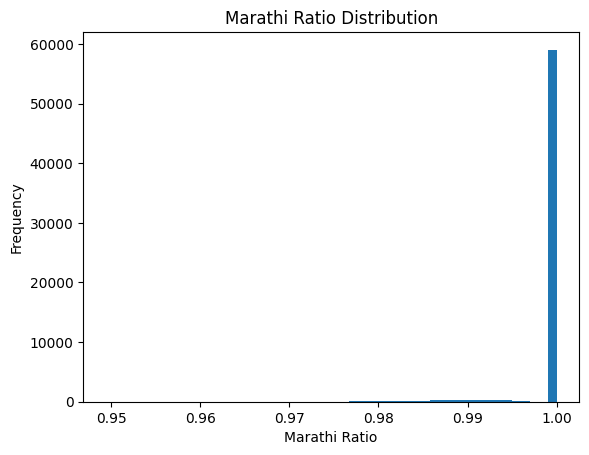

In [70]:
marathi_ratio_dist(df_train)

count    7902.000000
mean        0.999242
std         0.003227
min         0.969697
1%          0.982906
5%          0.992540
10%         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
90%         1.000000
95%         1.000000
99%         1.000000
max         1.000000
Name: input, dtype: float64


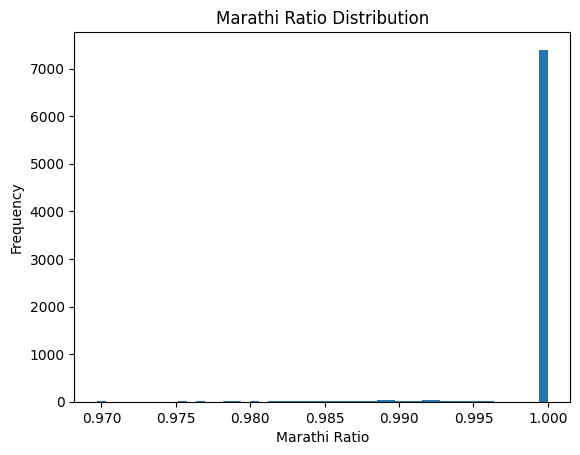

In [71]:
marathi_ratio_dist(df_test)

count    8010.000000
mean        0.999195
std         0.003590
min         0.941860
1%          0.982759
5%          0.992537
10%         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
90%         1.000000
95%         1.000000
99%         1.000000
max         1.000000
Name: input, dtype: float64


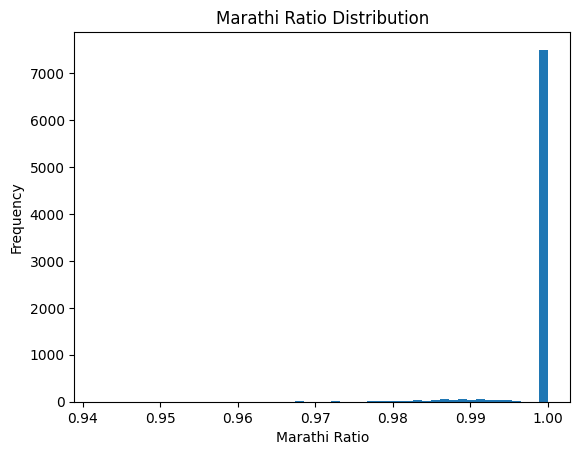

In [72]:
marathi_ratio_dist(df_val)

In [73]:
len(df_train), len(df_test), len(df_val)

(62793, 7902, 8010)

In [ ]:
def clean_by_marathi_perc(df: pd.DataFrame):
  marathi_ratio = df['article'].apply(calc_marathi_ratio)
  return df[(marathi_ratio >= 0.85)]

In [ ]:
df_train = clean_by_marathi_perc(df_train)

In [ ]:
df_test = clean_by_marathi_perc(df_test)

In [ ]:
df_val = clean_by_marathi_perc(df_val)

In [ ]:
len(df_train), len(df_test), len(df_val)

(9002, 1133, 1120)

In [74]:
print(df_train.sample(10))

                                                   input  \
28385  डोंबिवली : वार्ताहर मामेभावाने लैगिक शोषण झाल्...   
45987  टीम महाराष्ट्र देशा : राज्यात महाविकासआघाडीचे ...   
58405  परळी ः प्रतिनिधी साधुसंताप्रमाणे जीवनाची लक्षण...   
15552  टीम महाराष्ट्र देशा : आगामी लोकसभा निवडणुकीत व...   
19977  शेअर करा -अनिल भोईर दुबई येथे सुरू असलेल्या कब...   
4078   टीम महाराष्ट्र देशा : शिवसेनेचे माजी मंत्री ता...   
23670  पुणे : २०१९ मध्ये होणाऱ्या लोकसभा आणि विधानसभा...   
19117  सांगली - महापालिका निवडणुकीच्या पार्श्वभूमीवर ...   
68595  टीम महाराष्ट्र देशा : विधानसभा निवडणुकीचा उमेद...   
34604  सचिन तेंडुलकर आणि रेखा यांना जाहिराती करायला व...   

                                                  target  
28385        डोंबिवली : मामेभावाकडून तरुणीचे लैंगिक शोषण  
45987  दहा रुपयाला जर थाळी दिली तर जनता आळशी बनेल, सद...  
58405              गोपीनाथराव मुंडे कृपावंताचे जीवन जगले  
15552  आंबेडकरी जनतेचे मतदान महत्वाचे असेल तर रिपाइंस...  
19977  भारत आणि इराण कबड्डी मास्टर्सच्या अंत

In [75]:
df_train.isna().sum()

,0
input,0
target,0


In [95]:
!mkdir -p ./drive/MyDrive/stage_2_dataset_2_csv/indic_marathi_cleaned

In [76]:
df_train = df_train.reset_index(drop=True)

In [77]:
df_test = df_test.reset_index(drop=True)

In [78]:
df_val = df_val.reset_index(drop=True)

In [79]:
df_train.head()

,input,target
0,उपमुख्यमंत्री अजित पवार ः आम्ही सर्वजण उद्धव ठ...,मतभिन्नता असली तरी महाविकास आघाडी मजबूतच - अजि...
1,टीम महाराष्ट्र देशा : भारतीय हवाई दलाने नियंत्...,"मुख्यमंत्री आणि पोलीस यांच्यातील बैठक संपली , ..."
2,सांगली - सांगली शहरातील 100 फुटी रोड परिसरात न...,सांगलीत अज्ञातांकडून वाहनांची जाळपोळ
3,ऱ्या पावसामुळे महाराष्ट्रावर भीषण दुष्काळाचे स...,जालन्यात पाणी टंचाईने घेतला महिलेचा जीव
4,मुंबईत मुख्यमंत्री देवेंद्र फडणवीस यांच्या हस्...,लोकशाहीर अण्णाभाऊ साठे यांच्या टपाल तिकिटाचे ग...


In [81]:
df_test.head()

,input,target
0,नगर : प्रतिनिधी राज्यातील जलयुक्त शिवार अभियान...,भूजल पुनरुज्जीवन'मध्ये नगर जिल्हा सर्वोत्कृष्ट
1,पणजी : प्रतिनिधी बाबूश मोन्सेरात बलात्कार प्रक...,पीडित युवती बेपत्ता प्रकरणी चौकशीचे आदेश : मुख...
2,टीम महाराष्ट्र देशा - उस्मानाबाद जिल्हा खरीप प...,उस्मानाबाद जिल्हा खरीप पीक-विम्यातून वगळल्याच्...
3,ठाणे : पुढारी ऑनलाईन राम मंदिरासाठी शिवसेनेने ...,शिवसेनेच्या राम मंदिर आंदोलनाचे आम्ही स्वागत क...
4,पुणे : प्रतिनिधी राष्ट्रवादी काँग्रेसच्या प्रद...,राष्ट्रवादीच्या प्रदेशाध्यक्षांची उद्या पुण्या...


In [80]:
df_val.head()

,input,target
0,विहिरीमध्ये अज्ञात इसमाचा मृतदेह आढळल्याने खळब...,मोदींची मुख्यमंत्रीपदाची कारकिर्द देशावरचा डाग...
1,टीम महाराष्ट्र देशा : राज्यात विधानसभा निवडणुक...,शरद पवारांच्या 'या' भूमिकेचा शिवसेनेला बसला दणका
2,पुणे : प्रतिनिधी शालेय विद्यार्थ्यांची सुरक्षि...,"शाळा, पालकांमुळे खासगी वाहतूक फोफावणार"
3,नाशिक : प्रतिनिधी जुन्या भूसंपादन प्रकरणांबाबत...,भूसंपादनासाठी प्राधान्यक्रम निश्चित करा
4,पुणे - महसूलमंत्री चंद्रकांत पाटील यांच्याविरो...,चारही मुंड्या चितपट केलं नाही तर नाव नाही सांग...


In [82]:
len(df_train), len(df_test), len(df_val)

(62793, 7902, 8010)

In [83]:
df_train.isna().sum()

,0
input,0
target,0


In [84]:
df_test.isna().sum()

,0
input,0
target,0


In [85]:
df_val.isna().sum()

,0
input,0
target,0


In [98]:
df_train.to_csv('./drive/MyDrive/stage_2_dataset_2_csv/indic_marathi_cleaned/train.csv')

In [100]:
df_test.to_csv('./drive/MyDrive/stage_2_dataset_2_csv/indic_marathi_cleaned/test.csv')

In [101]:
df_val.to_csv('./drive/MyDrive/stage_2_dataset_2_csv/indic_marathi_cleaned/validation.csv')

In [ ]:
!zip -r /content/truncated_cleaned_marathi_csv.zip /content/truncated_cleaned_marathi_csv

  adding: content/truncated_cleaned_marathi_csv/ (stored 0%)
  adding: content/truncated_cleaned_marathi_csv/df_val_cleaned.csv (deflated 81%)
  adding: content/truncated_cleaned_marathi_csv/df_train_cleaned.csv (deflated 81%)
  adding: content/truncated_cleaned_marathi_csv/df_test_cleaned.csv (deflated 81%)


In [ ]:
!mv /content/truncated_cleaned_marathi_csv.zip /content/drive/MyDrive/stage_2_csv_datasets